# Crawl Overview: Fetch Outcomes, Category Distribution, Extraction Completeness

**Research question.** Given a diverse sample of real animal-rescue-related URLs, how
does the pipeline classify them (`STATION` / `LIST` / `IRRELEVANT`), how often does
fetching itself succeed, and - for pages the LLM decides are worth extracting data from -
how complete is the extracted record relative to the full field schema in `bot.config`?

**Data.** Produced by `experiments/collect_crawl_metrics.py`, which runs the real
fetch -> categorize -> extract pipeline (real Playwright fetches, the project's
configured LLM and category/field schema) over one URL per distinct domain from
`starting_urls.csv`, in file order (see the script's docstring for the exact selection
rule and for why the page text fed to the LLM is capped at a fixed length).

In [1]:
import sys
sys.path.insert(0, ".")
from plotting import set_style, savefig, load_csv, PALETTE
import matplotlib.pyplot as plt
import pandas as pd
import json

set_style()
df = load_csv("crawl_metrics.csv")
df["fetch_success"] = df["fetch_success"].astype(bool)
df

,url,domain,fetch_seconds,fetch_success,html_bytes,categorize_seconds,category,cleaned_text_chars,extract_seconds,extracted_count,extracted_json
0,https://rlp.nabu.de/tiere-und-pflanzen/tieren-...,rlp.nabu.de,3.788,True,90583,19.396,IRRELEVANT,1500.0,NaN,NaN,NaN
1,https://www.vbu-ffm.de/pflegestationen.shtml,www.vbu-ffm.de,1.265,True,29328,17.604,LIST,1500.0,24.335,0.0,[]
2,https://deutsche-wildtierrettung.de/wildtierau...,deutsche-wildtierrettung.de,3.092,True,128372,18.391,LIST,1500.0,24.234,0.0,[]
3,https://www.wildtierschutz-deutschland.de/wild...,www.wildtierschutz-deutschland.de,5.532,True,1031500,17.298,LIST,1500.0,24.195,0.0,[]
4,https://www.wildtierhilfe-odenwald.de/,www.wildtierhilfe-odenwald.de,0.110,False,0,NaN,NaN,NaN,NaN,NaN,NaN
5,http://wildstationbilche.de/,wildstationbilche.de,0.832,False,0,NaN,NaN,NaN,NaN,NaN,NaN
6,http://www.eichhoernchen-schutz.de/,www.eichhoernchen-schutz.de,7.628,True,179467,19.538,STATION,1500.0,40.465,14.0,"{""station_url"": ""https://eichhoernchen-schutz...."
7,http://eichhoernchen-notruf.com/,eichhoernchen-notruf.com,3.862,True,75365,20.373,STATION,1500.0,59.344,14.0,"{""station_url"": ""https://www.eichhoernchen-not..."
8,https://www.xn--eichhrnchen-in-not-h3b.de/,www.xn--eichhrnchen-in-not-h3b.de,2.454,True,56024,21.828,LIST,1500.0,27.691,0.0,[]
9,http://www.feldhasen.de/,www.feldhasen.de,3.474,True,55298,20.032,STATION,1500.0,42.826,14.0,"{""station_url"": ""https://www.wildtierwaisen-sc..."


## Fetch outcomes

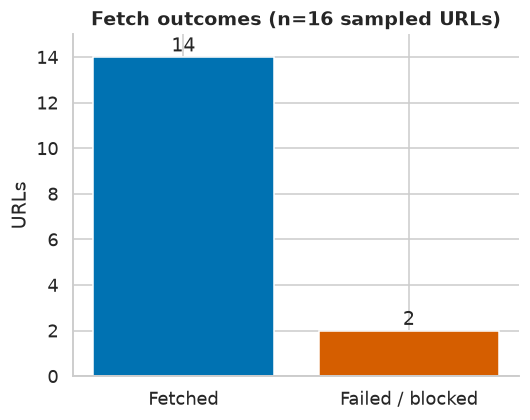

In [2]:
outcome_counts = df["fetch_success"].map({True: "Fetched", False: "Failed / blocked"}).value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(outcome_counts.index, outcome_counts.values, color=[PALETTE[0], PALETTE[1]])
for i, v in enumerate(outcome_counts.values):
    ax.text(i, v + 0.05, str(v), ha="center", va="bottom")
ax.set_ylabel("URLs")
ax.set_title(f"Fetch outcomes (n={len(df)} sampled URLs)")
ax.set_ylim(0, outcome_counts.max() + 1)
fig.tight_layout()
savefig(fig, "fetch_outcomes")
plt.show()

## Category distribution

Only successfully-fetched pages reach the categorization step, so the distribution below
is conditioned on `fetch_success`.

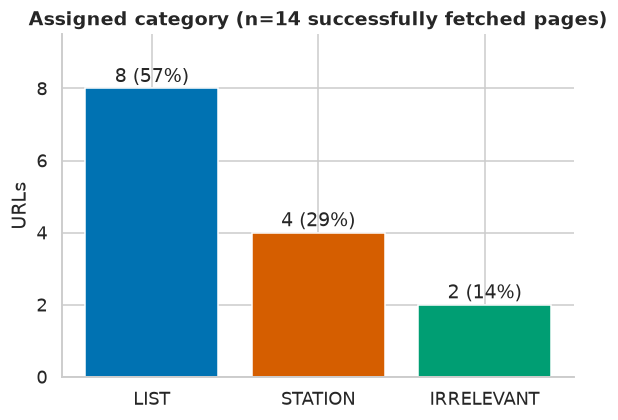

In [3]:
categorized = df[df["fetch_success"]]
category_counts = categorized["category"].value_counts()

fig, ax = plt.subplots(figsize=(5.5, 4))
colors = [PALETTE[i % len(PALETTE)] for i in range(len(category_counts))]
ax.bar(category_counts.index, category_counts.values, color=colors)
for i, v in enumerate(category_counts.values):
    pct = 100 * v / len(categorized)
    ax.text(i, v + 0.05, f"{v} ({pct:.0f}%)", ha="center", va="bottom")
ax.set_ylabel("URLs")
ax.set_title(f"Assigned category (n={len(categorized)} successfully fetched pages)")
ax.set_ylim(0, category_counts.max() + 1.5)
fig.tight_layout()
savefig(fig, "category_distribution")
plt.show()

## Extraction completeness

For pages the LLM judged relevant (`STATION`/`LIST`), the extraction prompt explicitly
instructs it to *leave out* fields it cannot fill from the page content, rather than
guessing - so a missing key in the extracted JSON is a meaningful "not found" signal, not
a formatting artifact. This counts, across all relevant extractions, how often each
schema field ended up present.

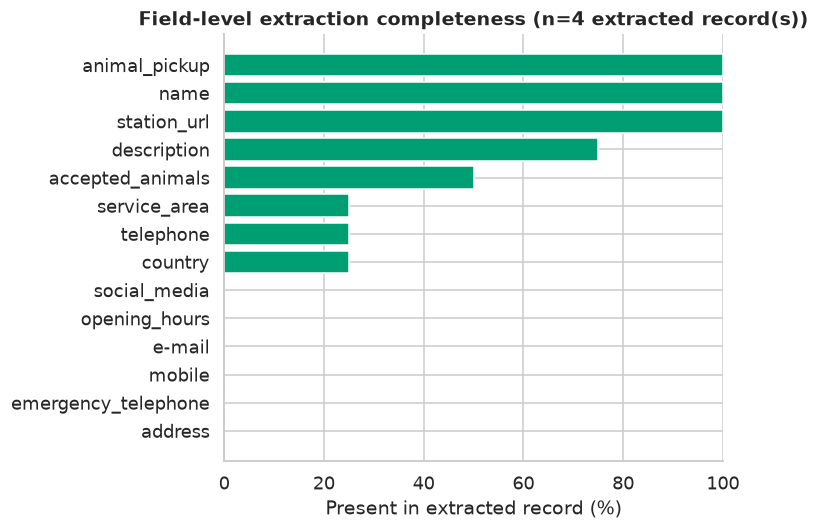

In [4]:
ALL_FIELDS = [
    "station_url", "name", "address", "country", "e-mail", "telephone", "mobile",
    "emergency_telephone", "social_media", "accepted_animals", "service_area",
    "animal_pickup", "opening_hours", "description",
]

extracted_rows = df[df["extracted_json"].notna() & (df["extracted_json"] != "")]

field_presence = {f: 0 for f in ALL_FIELDS}
n_records = 0
for _, row in extracted_rows.iterrows():
    records = json.loads(row["extracted_json"])
    if isinstance(records, dict):
        records = [records]
    for record in records:
        n_records += 1
        for f in ALL_FIELDS:
            if record.get(f) not in (None, "", []):
                field_presence[f] += 1

if n_records:
    completeness = pd.Series(field_presence).sort_values(ascending=True) / n_records * 100
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(completeness.index, completeness.values, color=PALETTE[2])
    ax.set_xlabel("Present in extracted record (%)")
    ax.set_title(f"Field-level extraction completeness (n={n_records} extracted record(s))")
    ax.set_xlim(0, 100)
    fig.tight_layout()
    savefig(fig, "extraction_completeness")
    plt.show()
else:
    print("No extracted records in this sample - nothing to plot.")

## Discussion

**Category distribution.** With only a small, diverse sample, this is not a
statistically representative picture of the wider web of animal-rescue-related pages -
`starting_urls.csv` itself is already a curated, high-relevance list (see the README) -
but it does sanity-check that the categorization step actually discriminates between
categories rather than collapsing everything into one bucket, and gives a rough sense of
how much of a real crawl's traffic ends up worth extracting from at all.

**Extraction completeness.** Contact-style fields (name, address) are expected to be
filled far more often than niche fields (e.g. `emergency_telephone`, `social_media`),
which most station websites simply don't publish - low completeness for such a field is
evidence of the *page* lacking the information, not necessarily of the extraction step
failing.

**Limitation - content truncation and list categories.** `collect_crawl_metrics.py`
caps the text fed to the LLM at a fixed length to keep this experiment's runtime
tractable on CPU (see its docstring). This appears to hit `LIST`-category pages harder
than `STATION` pages in this sample: list pages typically present their actual list of
entries further down the page (after navigation, introductory text, etc.), so a fixed
character cap is more likely to cut off before reaching them, whereas a single station's
own contact details tend to appear earlier. Where this notebook shows zero or few
extracted entries for `LIST` pages, that is a plausible truncation artifact of this
specific measurement script, not evidence that the production pipeline (which does not
truncate page content) would behave the same way.